In [ ]:
#Name: DUA ABBASI
#SECTION: G
#CMS-ID: 023-24-0229

In [6]:
# part 1.
# task 1 and task 2

In [7]:
import pandas as pd

df = pd.read_csv("clean_churn.csv")
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
y = df['Churn'].map({'Yes':1, 'No':0})
x = df.drop(columns=['Churn'])
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [9]:
cat_col = x.select_dtypes(include='object').columns
x = pd.get_dummies(x,cat_col,dtype=int)

x.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 45 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   tenure                                   7043 non-null   int64  
 2   MonthlyCharges                           7043 non-null   float64
 3   TotalCharges                             7043 non-null   float64
 4   gender_Female                            7043 non-null   int64  
 5   gender_Male                              7043 non-null   int64  
 6   Partner_No                               7043 non-null   int64  
 7   Partner_Yes                              7043 non-null   int64  
 8   Dependents_No                            7043 non-null   int64  
 9   Dependents_Yes                           7043 non-null   int64  
 10  PhoneService_No                          7043 no

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)
model = DecisionTreeClassifier(max_depth=5, random_state=42)

model.fit(x_train,y_train)

y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

print("Tree Depth:", model.get_depth())

dt_accuracy = accuracy_score(y_test, y_test_pred)
dt_precision = precision_score(y_test, y_test_pred)
dt_recall = recall_score(y_test, y_test_pred)
dt_f1 = f1_score(y_test, y_test_pred)

print("Accuracy:", dt_accuracy)
print("precision:", dt_precision)
print("recall:", dt_recall)
print("f1:", dt_f1)





Tree Depth: 5
Accuracy: 0.7984386089425124
precision: 0.6347305389221557
recall: 0.5668449197860963
f1: 0.5988700564971752


In [11]:
# part 2

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(x_train,y_train)

y_test_pred_rf = rf_model.predict(x_test)

accuracy_rf = accuracy_score(y_test,y_test_pred_rf)
precision_rf = precision_score(y_test,y_test_pred_rf)
recall_rf = recall_score(y_test,y_test_pred_rf)
f1_rf = f1_score(y_test,y_test_pred_rf)


print("Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("precision:", precision_score(y_test, y_test_pred_rf))
print("recall:", recall_score(y_test, y_test_pred_rf))
print("f1:", f1_score(y_test, y_test_pred_rf))

Accuracy: 0.7771469127040455
precision: 0.603448275862069
recall: 0.4679144385026738
f1: 0.5271084337349398


In [13]:
# Although random forest gives better results but in this particular example we are seeing that the results are not satisfying as 
# compare to single decision tree. 
# There can be multiple reasons for that: We have set the number of trees in random forest to be 200. As we have seen that decision tree
# does not perform well on high depth. Therefore, in my opinion this can be one reason for that. The other reasons are that the random 
# forest helps us to reduce overfitting but does not guarantee the optimal solution. 

In [14]:
# part 3

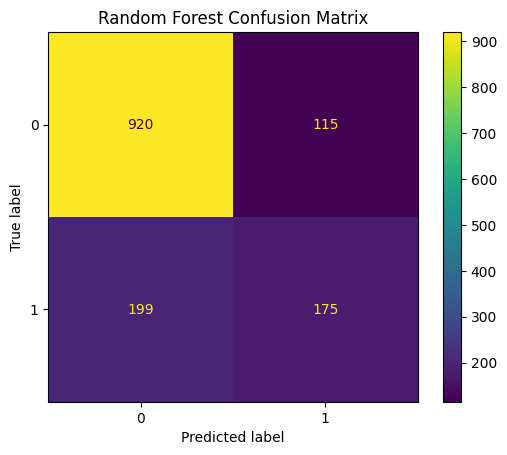

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()


In [16]:
# task 6

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 score'],

    'Decision Tree': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred)
    ],

    'Random Forest': [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf
    ]
})

comparison

In [17]:
# we can see that the Decision has performed better overall then random forest. 
# some matrix has marginal difference and some have large difference
# recall is the most important due to imbalance

In [18]:
# part 4

In [19]:
from sklearn.model_selection import cross_val_score

dt_scores = cross_val_score(model, x, y, cv=5, scoring='f1')

rf_scores = cross_val_score(rf_model, x, y, cv=5, scoring='f1')

print("Decision Tree F1 score:", dt_scores)
print("Decision Tree Mean F1 score:", dt_scores.mean())
print("Decision Tree Std F1 score:", dt_scores.std())

print()

print("Random Forest F1 score:", rf_scores)
print("Random Forest Mean F1 score:", rf_scores.mean())
print("Random Forest Std F1 score:", rf_scores.std())


Decision Tree F1 score: [0.61246612 0.62382865 0.59259259 0.5907781  0.57720058]
Decision Tree Mean F1 score: 0.5993732080724318
Decision Tree Std F1 score: 0.016619092795368173

Random Forest F1 score: [0.55877863 0.55555556 0.50598802 0.55641422 0.56363636]
Random Forest Mean F1 score: 0.5480745577145422
Random Forest Std F1 score: 0.021229877491558444


In [20]:
#task 9
# The cross validation results are consistent with single split results from part 3.
# The Decision Tree has a higher mean F1-score so it performs better on average then random forest.
# These results from cross validation are a strong evidence that the results are consistent and 
# Decision tree has performed well as compare to random forest.

In [21]:
# part 5

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring='f1'
)

grid_search.fit(x,y)


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,150


In [23]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated F1:", grid_search.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}
Best cross-validated F1: 0.5800421013957275


In [24]:
tuned_rf = grid_search.best_estimator_

y_pred_tuned = tuned_rf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred_tuned)
precision = precision_score(y_test, y_pred_tuned)
recall = recall_score(y_test, y_pred_tuned)
f1 = f1_score(y_test, y_pred_tuned) 

print('Accuracy:', accuracy)
print('precision:', precision)
print('Recall:', recall)
print('F1-score:', f1)

Accuracy: 0.872959545777147
precision: 0.8037383177570093
Recall: 0.6898395721925134
F1-score: 0.7424460431654676


In [25]:
# part 6:

In [26]:
comparison = pd.DataFrame({
    "Model": ['Decision Tree', "Default Random Forest", "Tuned Random Forest"],
    "Accuracy": [dt_accuracy, accuracy_rf, accuracy],
    "Precision": [dt_precision, precision_rf, precision],
    "Recall": [dt_recall, recall_rf, recall],
    "F1-score": [dt_f1, f1_rf, f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.798439,0.634731,0.566845,0.598870
1,Default Random Forest,0.777147,0.603448,0.467914,0.527108
2,Tuned Random Forest,0.872960,0.803738,0.689840,0.742446


In [27]:
# I will choose tuned Random Forest then any other model.
# The reason is visible above in a table where we can see that tuned random forest model has achieved
# the better results than any other model.

In [28]:
important = tuned_rf.feature_importances_

feature_importance = pd.Series(
    important, index = x.columns
).sort_values(ascending=False)

top_five = feature_importance.head(5)
print(top_five)

tenure                     0.142243
TotalCharges               0.130257
Contract_Month-to-month    0.093024
MonthlyCharges             0.088581
OnlineSecurity_No          0.055579
dtype: float64


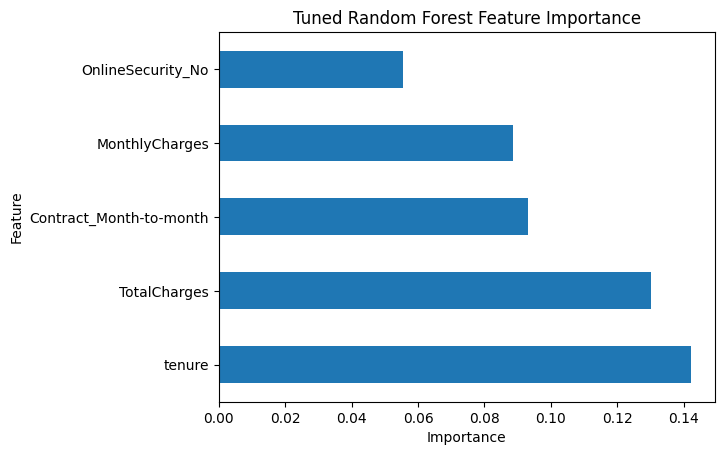

In [29]:
top_five.plot(kind="barh")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Tuned Random Forest Feature Importance")
plt.show()

In [30]:
# The 5 most important features are tenure, total_Charges, contract_month_to_month, and 
# monthly_charges and online_security_no.
# These results mostly agree with our lab2 where we found that features such as tenure, charges are
# important to find the customer churn.


In [31]:
# part 7

In [36]:
original_df = pd.read_csv("original_churn.csv")

original_df["customerID"].head()

0    7590-VHVEG
1    5575-GNVDE
2    3668-QPYBK
3    7795-CFOCW
4    9237-HQITU
Name: customerID, dtype: object

In [37]:
customer_ids = original_df.loc[x_test.index, "customerID"]

submission = pd.DataFrame({
    "customerID" : customer_ids,
    "Churn": y_pred_tuned
})

submission.to_csv("submission.csv", index=False)

submission.head()

,customerID,Churn
437,4376-KFVRS,0
2280,2754-SDJRD,1
2235,9917-KWRBE,0
4460,0365-GXEZS,0
3761,9385-NXKDA,0


In [ ]:
# task 17

In [ ]:
# I selected the Tuned Random forest model because it gave the optimal solution of all models.
# This model provided better results than lab3 simple Decisiontree model.
# The most important features were tenure, totalcharges, onlinesecurity etc
# The model has some limitations such as low recall which means the model failed to recognize some of the customers who churn.

In [ ]:
# task 18

In [ ]:
# If i had more time i would probably try diff models and see their results.
# I would also pedantically tune the existing features to see if the results are improved.